## Установка нужных версий библиотек

In [ ]:
!wget 'https://drive.google.com/uc?export=download&id=1oSFOP0j25OZAuhD8YXxyQXNTdr2lUdtn' -O requirements.txt

--2021-07-16 17:58:33--  https://drive.google.com/uc?export=download&id=1oSFOP0j25OZAuhD8YXxyQXNTdr2lUdtn
Resolving drive.google.com (drive.google.com)... 172.217.2.110, 2607:f8b0:4004:829::200e
Connecting to drive.google.com (drive.google.com)|172.217.2.110|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://doc-0g-c0-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/sg8pmih5oflperk12g9f5nmtrr6l1h3d/1626458250000/14904333240138417226/*/1oSFOP0j25OZAuhD8YXxyQXNTdr2lUdtn?e=download [following]
--2021-07-16 17:58:33--  https://doc-0g-c0-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/sg8pmih5oflperk12g9f5nmtrr6l1h3d/1626458250000/14904333240138417226/*/1oSFOP0j25OZAuhD8YXxyQXNTdr2lUdtn?e=download
Resolving doc-0g-c0-docs.googleusercontent.com (doc-0g-c0-docs.googleusercontent.com)... 172.217.164.129, 2607:f8b0:4004:814::2001
Connecting to doc-0g-c0-docs.googleusercontent.com (doc-0g-c0-docs.g

In [ ]:
!pip install -r requirements.txt

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Переобучение - явление, когда построенная модель хорошо объясняет примеры из обучающей выборки, но относительно плохо работает на примерах, не участвовавших в обучении (на примерах из тестовой выборки).

Для лучшего усвоения переобучения сначала ознакомьтесь с метриками для задачи регрессии ([видео на youtube](https://youtu.be/vh2smjQyhp8) и [ноутбук](https://colab.research.google.com/drive/14Oxi6sI25mP4JbovLiJ57e7H5sbN2I3p)) и алгоритмом построения дерева решений ([видео на youtube](https://youtu.be/0mMeaC3gjNI) и [ноутбук](https://colab.research.google.com/drive/1AF5iURw-R0hPejwxWLi2VspI2BJrCsvl)).

Переобучение визуально показано на картинке ниже, в этом случае модель слишком хорошо запомнила обучающую выборку, подогналась под примеры и не стала изучать общую закономерность в данных.

<img src='https://drive.google.com/uc?export=view&id=189kw3wJRkeZYEZDvrRZsHiNb-7Sgf4Cj'>

Теперь давайте сами поймаем переобучение на синтетических данных, сгенерированных с помощью sklearn'a.

## Генерация данных

Будем работать с набором данных для задачи регрессии (вещественная целевая переменная). Получим через метод `make_regression` данные, состоящие из одного информативного признака (`n_features=1, n_informative=1`) в количестве 100 штук (`n_samples=100`) для предсказания одной целевой переменной (`n_targets=1`) и добавим немного шума (`noise=6`), чтобы усложнить жизнь модели.

Для простоты визуализаций переобучения возьмем один признак и на его основе будем строить модель машинного обучения.

In [ ]:
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1,
    n_targets=1,
    noise=10,
    random_state=42
)
display(X, y)

array([[ 0.93128012],
       [ 0.08704707],
       [-1.05771093],
       [ 0.31424733],
       [-0.47917424],
       [ 0.64768854],
       [-0.46341769],
       [ 0.54256004],
       [ 0.61167629],
       [ 1.0035329 ],
       [ 0.8219025 ],
       [ 1.53803657],
       [ 0.73846658],
       [-0.21967189],
       [-0.8084936 ],
       [ 0.09176078],
       [-1.95967012],
       [ 0.51326743],
       [ 1.03099952],
       [-2.6197451 ],
       [ 0.49671415],
       [ 0.09707755],
       [-0.46572975],
       [ 0.91540212],
       [ 1.56464366],
       [ 1.46564877],
       [-0.60063869],
       [-0.03582604],
       [-0.60170661],
       [-1.19620662],
       [ 0.35711257],
       [ 0.37569802],
       [ 0.26105527],
       [-0.5297602 ],
       [-0.90802408],
       [ 0.19686124],
       [-0.29900735],
       [ 0.36163603],
       [ 0.82254491],
       [-0.29169375],
       [ 0.36139561],
       [-0.676922  ],
       [ 1.52302986],
       [-0.51827022],
       [-0.23415337],
       [-0

array([  50.77992943,  -10.06527016,  -34.91839191,   10.52674299,
        -17.73837724,   31.56459551,  -30.06888275,    5.91200699,
         23.47337416,   32.34359474,   35.76573341,   76.88323383,
         36.18776792,    2.9244734 ,  -47.81146525,   12.61693126,
        -85.45418019,   20.05162924,   28.63464002, -118.02745409,
         16.77823077,    2.81079984,  -29.36593416,   28.57973536,
         74.71530364,   64.57600193,  -11.01926675,    2.74944415,
        -33.92230425,  -62.09952962,   20.28587171,   29.52220586,
          5.76708113,  -21.69297316,  -43.6490161 ,   -4.01153077,
        -20.19870331,    7.58329135,   51.39997923,    1.74763946,
         22.78482382,  -31.5003787 ,   61.91233294,  -20.69551487,
         -7.6244312 ,   -5.91131407,  -14.17777333,  -38.23228892,
         23.49423306,    8.80963973,   -5.90648058,    7.31453371,
        -29.99628354,   89.03314517,    9.31786907,   24.7816116 ,
         20.00370858,    0.72440436,   -8.86713635,  -85.35925

Получили 100 объектов из одного признака, можем их визуализировать.

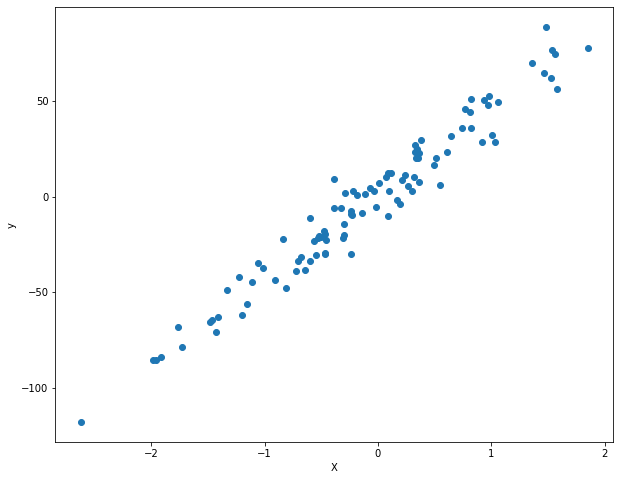

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y');

Разобьем выборку на две: обучающую и тестовую. Чтобы на обучение модель уловила зависимости, а на тесте мы могли бы проверить, как модель будет работать на новых данных, на которых она не обучалась.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((80, 1), (80,), (20, 1), (20,))

### Overfitting

Возьмем модель дерево решений из `sklearn'a` и обучим на обучающей выборке.



In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_over = DecisionTreeRegressor(
    random_state=1
)
tree_over.fit(X_train, y_train)

DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=None,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=1, splitter='best')

Теперь посчитаем метрику качества работы модели на обучащей выборке. Будем считать средне-квадратичную ошибку.

In [ ]:
from sklearn.metrics import mean_squared_error


pred_train_over = tree_over.predict(X_train)
mse_train_over = mean_squared_error(y_train, pred_train_over)

print(f'MSE на обучении {mse_train_over:.2f}')

MSE на обучении 0.00


Получился 0 - это идеально для метрики MSE, т.к. чем она ближе к нулю, тем лучше, это значит, что во все целевые значения из обучающей выборки наша модель идеально попала. Все значения предсказаны верно. Можем в этом убедиться, построив соответствие истинных значений и предсказанных:


In [ ]:
pd.DataFrame({
    'ground truth': y_train,
    'prediction': pred_train_over
})

,ground truth,prediction
0,24.781612,24.781612
1,-37.499144,-37.499144
2,-11.019267,-11.019267
3,61.912333,61.912333
4,46.073157,46.073157
...,...,...
75,27.166487,27.166487
76,-63.166093,-63.166093
77,-47.811465,-47.811465
78,10.491670,10.491670


Что и требовалось доказать, во все значения с обучения (`ground truth`) наши предсказания (`prediction`) попали.

Можем визуализировать закон, который восстановило дерево решений.  
Сгенерируем точки в количество 1000 штук от наименьшего объекта с обучающей выборки до наибольшего и для всех этих точек сделаем предсказания обученной моделькой.

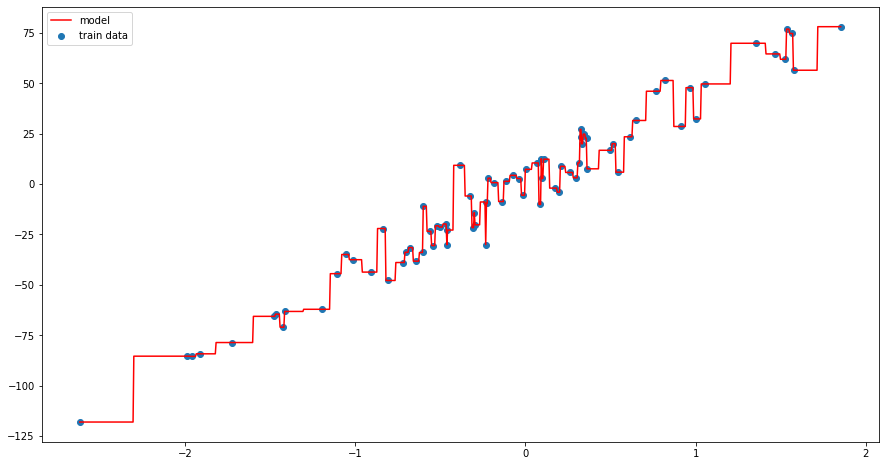

In [ ]:
dots = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)
pred_dots_over = tree_over.predict(dots)

plt.figure(figsize=(15, 8))
plt.plot(dots, pred_dots_over, c='r', label='model');
plt.scatter(X_train, y_train, label='train data')
plt.legend();

Моделька умудрилась попасть во все точки с обучения, закон (красная линия) проходит через все объекты с обучения (синия точки), кажется, что всё идеально, но стоит нам сделать предсказания на тестовых точках, как всё перестает быть таким радужным:

In [ ]:
pred_test_over = tree_over.predict(X_test)
mse_test_over = mean_squared_error(y_test, pred_test_over)

print(f'MSE на тесте {mse_test_over:.2f}')

MSE на тесте 226.23


Метрика качества MSE на тесте совсем не близка к нулю, а значит, что модель не смогла точно предсказать объекты с тестовой выборки.

In [ ]:
pd.DataFrame({
    'ground truth': y_test,
    'prediction': pred_test_over
})

,ground truth,prediction
0,-48.949080,-63.166093
1,89.033145,64.576002
2,44.409196,51.399979
3,-5.911314,9.317869
4,-7.624431,-29.996284
5,1.747639,-20.198703
6,-29.365934,-30.068883
7,-68.326754,-78.591791
8,35.765733,51.399979
9,50.779929,28.579735


Так и есть, предсказания тестовых объектов далеки от истинных значений, где-то модель ошибается больше, где-то не так сильно.

Ещё раз визуализируем закон, который восстановило дерево решений.  
И отобразим истинные значения тестовых точек на этом законе синим цветом, а красным цветом раскрасим предсказания модели.

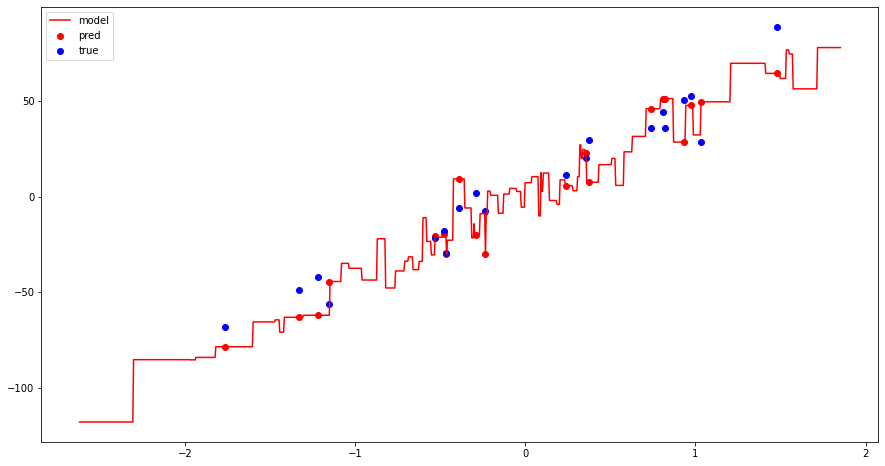

In [ ]:
plt.figure(figsize=(15, 8))
plt.plot(dots, pred_dots_over, c='r', label='model');
plt.scatter(X_test, pred_test_over, c='r', label='pred')
plt.scatter(X_test, y_test, c='b', label='true')
plt.legend();

Красная линия не проходит через тестовые точки, а значит, что модель работает не лучшим образом на данных, на которых она не обучалась, что нам не играет на руку, ведь мы хотим, чтобы обученная нами модель работала хорошо на всех данных по этой задаче, даже на тех, которые она никогда в жизни не видела.

Ведь обычно, у нас есть только маленький кусочек данных относительно всего массива объектов, на котором мы хотим в дальнейшем предсказывать целевые значения.

Наша модель не стала искать закон, которому следуют все данные из этой задаче, а только запомнила объекты из обучения - это и есть **переобучение** (*overfitting*, или же русский аналог *подгонка*).   
Здесь будет идеальная метрика качества на обучающей выборке, а на тестовой выборке метрика будет плохая.

### Underfitting

Давайте теперь посмотрим на недообучение, когда модель настолько простая, что не может запомнить ничего, ни обучающую выборке, ни данные в целом.

Возьмем модель дерево решений из `sklearn'a` и изменим у неё параметры очень сильно ограничев её сложность и обучим на обучающей выборке.



In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_under = DecisionTreeRegressor(
    random_state=1,
    max_depth=1,
)
tree_under.fit(X_train, y_train)

DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=1,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=1, splitter='best')

Посчитаем средне-квадратичную ошибку.

In [ ]:
pred_train_under = tree_under.predict(X_train)
mse_train_under = mean_squared_error(y_train, pred_train_under)

print(f'MSE на обучении {mse_train_under:.2f}')

MSE на обучении 678.76


Получилось большое значение метрики MSE, значит, что у модели дела не очень хорошо и она не смогла запомнить обучающую выборку.

In [ ]:
pd.DataFrame({
    'ground truth': y_train,
    'prediction': pred_train_under
})

,ground truth,prediction
0,24.781612,23.667856
1,-37.499144,-39.598835
2,-11.019267,-39.598835
3,61.912333,23.667856
4,46.073157,23.667856
...,...,...
75,27.166487,23.667856
76,-63.166093,-39.598835
77,-47.811465,-39.598835
78,10.491670,23.667856


Наши предсказания даже близко не находятся с истинными значениями.

Визуализируем закон, который выучила модель дерево решений.

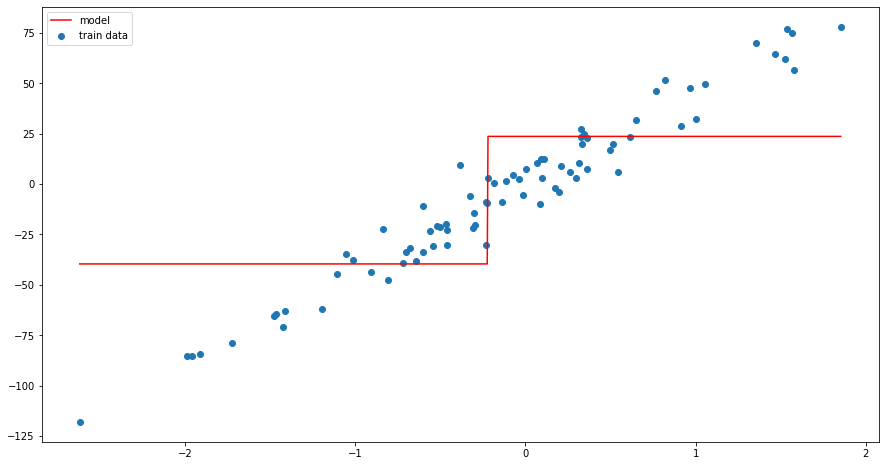

In [ ]:
dots = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)
pred_dots_under = tree_under.predict(dots)

plt.figure(figsize=(15, 8))
plt.plot(dots, pred_dots_under, c='r', label='model');
plt.scatter(X_train, y_train, label='train data')
plt.legend();

Вот такой интересный закон, состоящий из одной ступеньки смогла запомнить наша модель, общую тендецию данных она попыталась уловить, но результаты предсказаний далеки от истинных значений целевой переменной.

Посмотрим, как будет на тесте:

In [ ]:
pred_test_under = tree_under.predict(X_test)
mse_test_under = mean_squared_error(y_test, pred_test_under)

print(f'MSE на тесте {mse_test_under:.2f}')

MSE на тесте 639.17


Метрика качества MSE на тесте тоже далека от нуля, а значит, что модель не смогла выучить и общий смысл данных.

In [ ]:
pd.DataFrame({
    'ground truth': y_test,
    'prediction': pred_test_under
})

,ground truth,prediction
0,-48.949080,-39.598835
1,89.033145,23.667856
2,44.409196,23.667856
3,-5.911314,-39.598835
4,-7.624431,-39.598835
5,1.747639,-39.598835
6,-29.365934,-39.598835
7,-68.326754,-39.598835
8,35.765733,23.667856
9,50.779929,23.667856


Предсказания тестовых объектов располагаются очень далеко от истинных значений.

Снова визуализация.

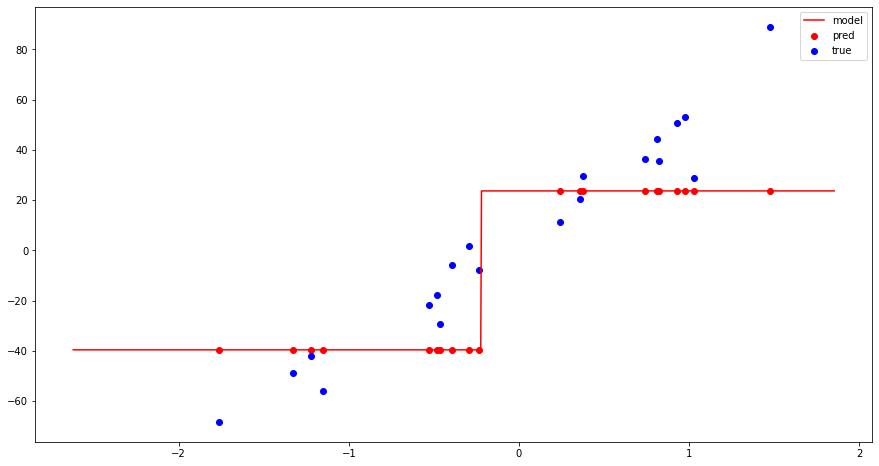

In [ ]:
plt.figure(figsize=(15, 8))
plt.plot(dots, pred_dots_under, c='r', label='model');
plt.scatter(X_test, pred_test_under, c='r', label='pred')
plt.scatter(X_test, y_test, c='b', label='true')
plt.legend();

Красная линия снова не проходит через тестовые точки, а значит модель не поняла, в чем суть задачи, но при этом модель не смогла запомнить обучющую выборку, когда такое случается, значит модель находится в **недообучении** (*underfitting*).

Здесь будет довольно плохая метрика качества на обучающей выборке и на тестовой выборке будет такая же плохая метрика.

### Normal fitting

Ну и давайте наконец-то обучим нормально нашу модель, когда она не будет зазубривать обучающую выборку, но и когда она в целом, поймет устройство данных по нашей задаче.

Возьмем снова модель дерево решений и поставим ей параметры, которые более менее подходят для этой задачи.



In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_ok = DecisionTreeRegressor(
    random_state=1,
    max_depth=4,
    min_samples_leaf=3
)
tree_ok.fit(X_train, y_train)

DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=4,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=3, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=1, splitter='best')

Посчитаем средне-квадратичную ошибку.

In [ ]:
pred_train_ok = tree_ok.predict(X_train)
mse_train_ok = mean_squared_error(y_train, pred_train_ok)

print(f'MSE на обучении {mse_train_ok:.2f}')

MSE на обучении 58.63


Получилась не нулевая метрика MSE, но и не гигантская, значит, что у модели дела пошли в гору и она в не стала запоминать обучающую выборку.

In [ ]:
pd.DataFrame({
    'ground truth': y_train,
    'prediction': pred_train_ok
})

,ground truth,prediction
0,24.781612,23.646173
1,-37.499144,-40.124465
2,-11.019267,-22.444672
3,61.912333,65.450114
4,46.073157,42.017624
...,...,...
75,27.166487,23.646173
76,-63.166093,-65.411368
77,-47.811465,-35.176234
78,10.491670,0.569629


Где-то предсказания близки к истинным, где-то совсем далеки.

Визуализируем закон, который выучила модель дерево решений.

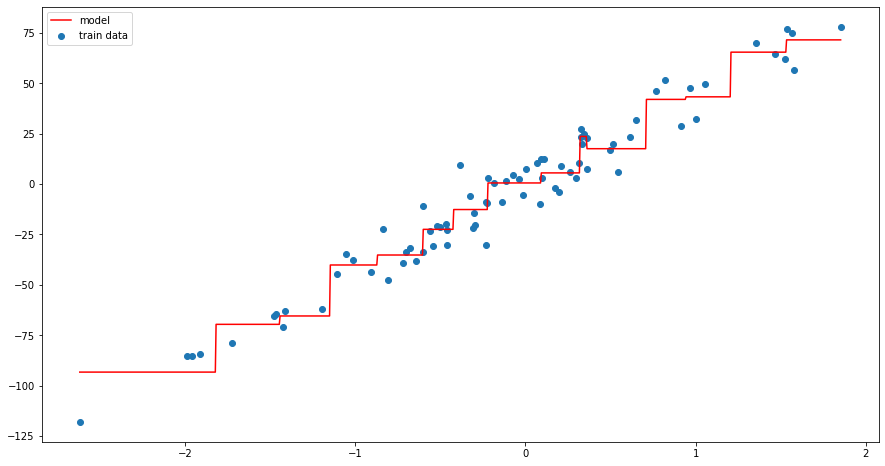

In [ ]:
dots = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)
pred_dots_ok = tree_ok.predict(dots)

plt.figure(figsize=(15, 8))
plt.plot(dots, pred_dots_ok, c='r', label='model');
plt.scatter(X_train, y_train, label='train data')
plt.legend();

Радует, что модель не стала строить закон, который проходит через все точки обучающей выборки, значит она пошла дальше и не стала заниматься зубрежкой обучающего набора, а пытается уловить общую закономерност данных.

Глянем на тест:

In [ ]:
pred_test_ok = tree_ok.predict(X_test)
mse_test_ok = mean_squared_error(y_test, pred_test_ok)

print(f'MSE на тесте {mse_test_ok:.2f}')

MSE на тесте 130.75


Метрика качества MSE не нулевая, но и не огромная, больше обучающей, но это не так страшно, т.к. данные у нас очень зашумленные и их мало.

In [ ]:
pd.DataFrame({
    'ground truth': y_test,
    'prediction': pred_test_ok
})

,ground truth,prediction
0,-48.949080,-65.411368
1,89.033145,65.450114
2,44.409196,42.017624
3,-5.911314,-12.613098
4,-7.624431,-12.613098
5,1.747639,-12.613098
6,-29.365934,-22.444672
7,-68.326754,-69.566570
8,35.765733,42.017624
9,50.779929,42.017624


Предсказания тестовых объектов плюс минус ходят рядом с истинными значениями.

Любимая визуализация.

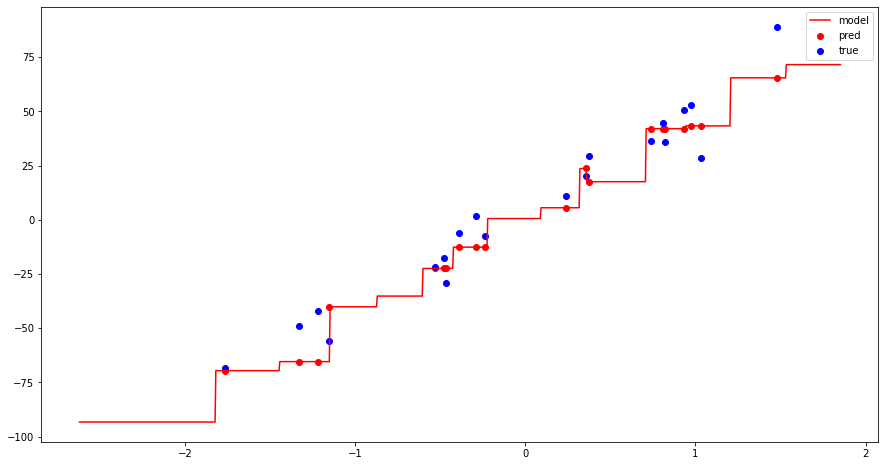

In [ ]:
plt.figure(figsize=(15, 8))
plt.plot(dots, pred_dots_ok, c='r', label='model');
plt.scatter(X_test, pred_test_ok, c='r', label='pred')
plt.scatter(X_test, y_test, c='b', label='true')
plt.legend();

Красная линия не проходит через тестовые точки, но она проходит где-то в окрестности истинных значений, а значит модель попыталась запомнить основной смысл данных и попыталась восстановить эту зависимсоть между X и y.

Здесь показано более менее адекватное обучение, здесь будет довольно неплохая метрика качества на обучающей выборке, так же как и на тестовой выборке.

## Summary

Построим все три графика рядом.  
**Недообучение** - модель даже не попыталась понять, что происходит с данными.  
**Идеальное обучение** - модель уловила общий посыл данных.   
**Переобучение** - модель так сильно старалась понять, в чем суть данных, что запомнила всё, что есть на обучении.

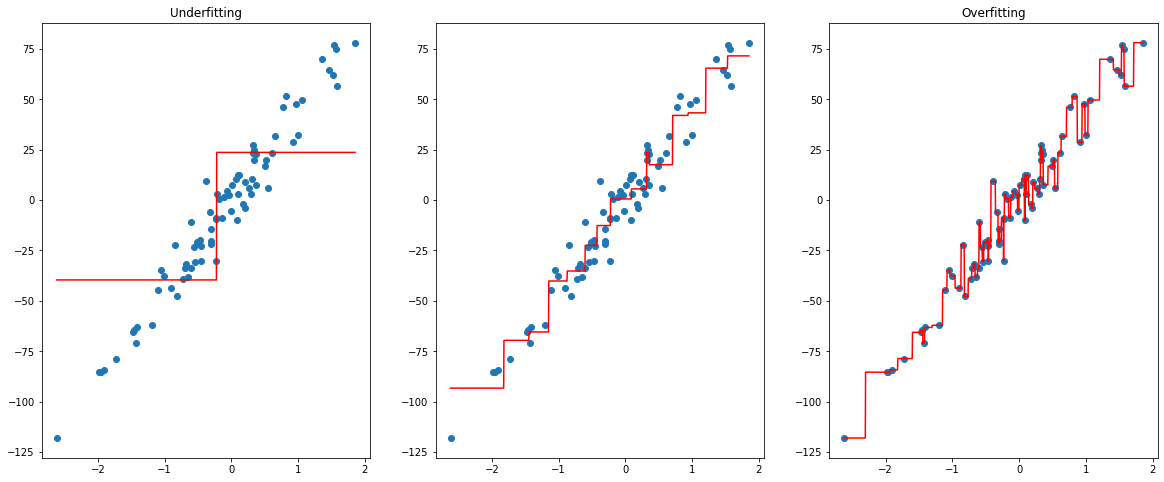

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 8))


ax[0].plot(dots, pred_dots_under, c='r');
ax[0].scatter(X_train, y_train)
ax[0].set_title('Underfitting')

ax[1].plot(dots, pred_dots_ok, c='r');
ax[1].scatter(X_train, y_train)

ax[2].plot(dots, pred_dots_over, c='r');
ax[2].scatter(X_train, y_train)
ax[2].set_title('Overfitting');

Объединим все наши цифры метрик качества в один датафрейм и сравним:

In [ ]:
mses = [
    [mse_train_under, mse_train_ok, mse_train_over],
    [mse_test_under, mse_test_ok, mse_test_over]
]

In [ ]:
pd.DataFrame(
    mses,
    columns=['Under', 'OK', 'Over'], index=['Train', 'Test']
)

,Under,OK,Over
Train,678.756338,58.626306,0.000000
Test,639.166837,130.747148,226.228792


**Недообучение** - метрики плохие и на обучении и на тесте.   
**Хорошее обучение** - метрики обе довольно неплохие.   
**Переобучение** - метрика на обучении отличная, а на тесте не всё так хорошо.

В этом ноутбуке посмотрели, через какие стадии может проходить модель при обучении на примере обучения модель дерево решений на искусственных данных. На реальных данных происходит всё так же, только признаков больше, задачи сложнее и это не всё так наглядно можно продемонстрировать, но принципы все такие же.

Муррр ♥